In [16]:
import pandas as pd

df = pd.read_csv("heart_failure_no_time.csv")  # your uploaded file

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(9)
memory usage: 28.2 KB


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop("DEATH_EVENT", axis=1)
y = df["DEATH_EVENT"]

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for SHAP compatibility
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

X_train_scaled_df.head()


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking
0,-0.269050,1.110696,-0.200735,-0.900337,0.176528,-0.770281,-1.004722,-0.360437,0.559915,-1.333818,-0.682831
1,-0.706883,-0.900337,-0.534318,1.110696,1.847425,-0.770281,1.051685,-0.544467,-0.345802,0.749728,-0.682831
2,1.219579,-0.900337,-0.020580,-0.900337,-1.494369,1.298227,0.013401,0.467698,-1.477949,0.749728,-0.682831
3,0.256348,-0.900337,-0.455129,-0.900337,-1.076645,-0.770281,-0.178127,0.927773,-0.345802,0.749728,-0.682831
4,-1.407414,-0.900337,-0.020580,-0.900337,-1.494369,1.298227,-1.387778,0.191653,-0.345802,0.749728,-0.682831


In [18]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train XGBoost model
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

xgb.fit(X_train_scaled_df, y_train)

# Predictions
y_pred = xgb.predict(X_test_scaled_df)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.7666666666666667

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.90      0.84        41
           1       0.69      0.47      0.56        19

    accuracy                           0.77        60
   macro avg       0.74      0.69      0.70        60
weighted avg       0.76      0.77      0.75        60


Confusion Matrix:
 [[37  4]
 [10  9]]


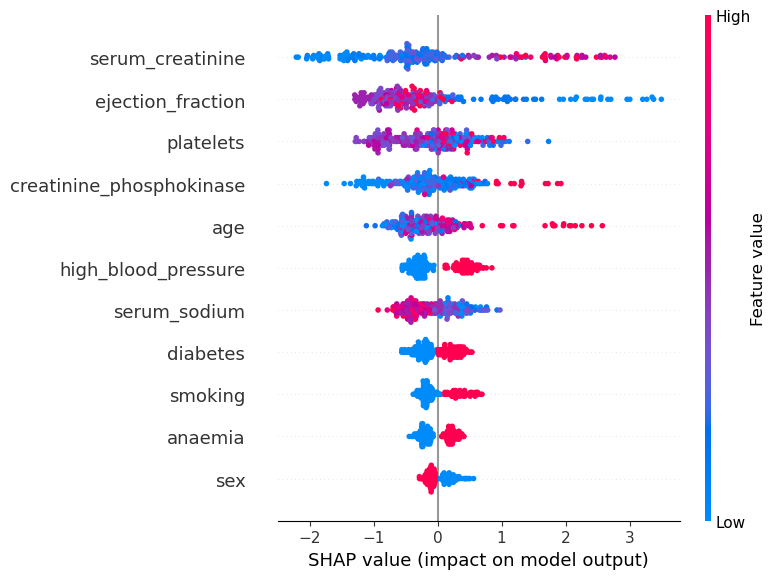

In [19]:
import shap

# Init JS
shap.initjs()

# Create SHAP explainer for XGBoost
explainer = shap.TreeExplainer(xgb)

# Compute SHAP values (disable additivity check to avoid errors)
shap_values = explainer.shap_values(X_train_scaled_df, check_additivity=False)

# Plot summary for feature importance
shap.summary_plot(
    shap_values,
    X_train_scaled_df,
    feature_names=X.columns
)


WHAT THE SYSTEM WILL DO (FINAL FUNCTIONAL SYSTEM)
🔥 1. Predict Risk

High Risk (1) → Patient has high probability of heart failure mortality

Low Risk (0) → Patient is stable but still monitored

🔥 2. Explain WHY

Using SHAP, the system will show:

Top 5 factors increasing risk

Personalized explanations (per patient)

Global feature importance (for doctors)

Example explanations:

“High serum creatinine + low sodium + low ejection fraction → high risk”

“Young, normal creatinine, normal EF → low risk”

🔥 3. Provide Medical Guidance

For high-risk patients:

What is abnormal

What it means medically

What immediate actions doctors should take

For low-risk patients:

Healthy indicators

Preventive care

Lifestyle improvement

🔥 4. Provide Final Doctor Summary

A fully generated report:

Patient Risk Category: HIGH
Top Risk Contributors:

Low Ejection Fraction (critically low)

High Serum Creatinine

Low Serum Sodium
Clinical Guidance:

Immediate cardiology evaluation

Start ACE inhibitors

Monitor kidney function weekly

Sodium regulation

In [20]:
y_prob = xgb.predict_proba(X_test_scaled_df)[:, 1]
y_prob[:10]  # preview first 10 probabilities


array([0.41335166, 0.03845476, 0.45351544, 0.79711795, 0.09801968,
       0.23094642, 0.02942881, 0.5181555 , 0.02395642, 0.9585078 ],
      dtype=float32)

This will allow us to:

✔ Classify patients as HIGH RISK or LOW RISK using a threshold (0.25 or 0.30)
✔ Provide personalized explanation using SHAP
✔ Generate medical recommendations based on top risk fa

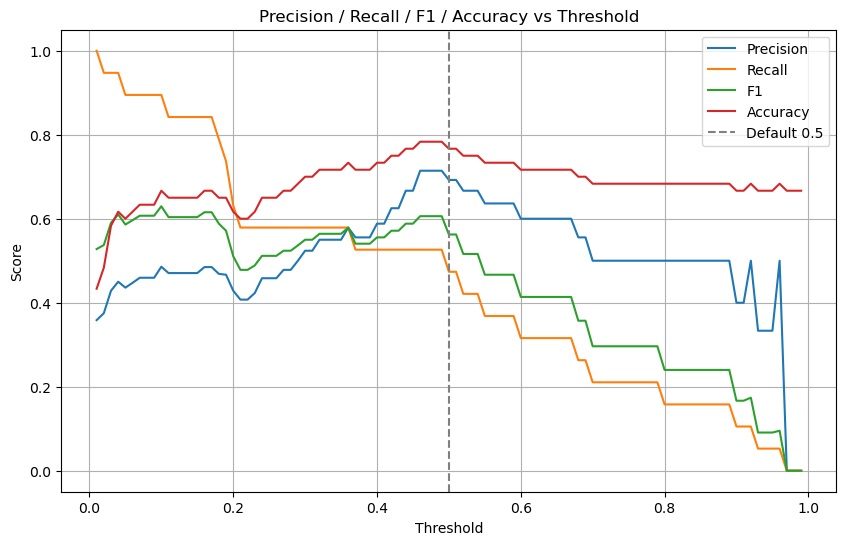

Best threshold by F1: 0.10 → Precision=0.49, Recall=0.89, F1=0.63, Acc=0.67

Thresholds with Recall >= 0.80 (top 5 by precision):
 t=0.10 → Prec=0.49, Rec=0.89, F1=0.63, Acc=0.67
 t=0.16 → Prec=0.48, Rec=0.84, F1=0.62, Acc=0.67
 t=0.17 → Prec=0.48, Rec=0.84, F1=0.62, Acc=0.67
 t=0.04 → Prec=0.45, Rec=0.95, F1=0.61, Acc=0.62
 t=0.07 → Prec=0.46, Rec=0.89, F1=0.61, Acc=0.63

Sample thresholds (0.1 increments):
 t=0.10 → Prec=0.49, Rec=0.89, F1=0.63, Acc=0.67
 t=0.20 → Prec=0.43, Rec=0.63, F1=0.51, Acc=0.62
 t=0.30 → Prec=0.52, Rec=0.58, F1=0.55, Acc=0.70
 t=0.40 → Prec=0.59, Rec=0.53, F1=0.56, Acc=0.73
 t=0.50 → Prec=0.69, Rec=0.47, F1=0.56, Acc=0.77
 t=0.60 → Prec=0.60, Rec=0.32, F1=0.41, Acc=0.72
 t=0.70 → Prec=0.50, Rec=0.21, F1=0.30, Acc=0.68
 t=0.80 → Prec=0.50, Rec=0.16, F1=0.24, Acc=0.68
 t=0.90 → Prec=0.40, Rec=0.11, F1=0.17, Acc=0.67

Recommended threshold (default = best F1): 0.10

Confusion matrix at recommended threshold:
[[23 18]
 [ 2 17]]

Classification report at recommend

In [21]:
# Step: Threshold tuning & helper function
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

# predicted probabilities for class 1
y_prob = xgb.predict_proba(X_test_scaled_df)[:, 1]

# thresholds to try
thresholds = np.linspace(0.01, 0.99, 99)

results = []
for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    acc = accuracy_score(y_test, y_pred_t)
    results.append((t, prec, rec, f1, acc))

results = np.array(results, dtype=float)

# Plotting
plt.figure(figsize=(10,6))
plt.plot(results[:,0], results[:,1], label='Precision')
plt.plot(results[:,0], results[:,2], label='Recall')
plt.plot(results[:,0], results[:,3], label='F1')
plt.plot(results[:,0], results[:,4], label='Accuracy')
plt.axvline(0.5, color='grey', linestyle='--', label='Default 0.5')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 / Accuracy vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

# Print top thresholds
# Best by F1
best_idx_f1 = np.argmax(results[:,3])
best_t_f1, best_prec_f1, best_rec_f1, best_f1, best_acc_f1 = results[best_idx_f1]
print(f"Best threshold by F1: {best_t_f1:.2f} → Precision={best_prec_f1:.2f}, Recall={best_rec_f1:.2f}, F1={best_f1:.2f}, Acc={best_acc_f1:.2f}")

# Thresholds achieving recall >= 0.8 (if any), sorted by precision
rec_target = 0.80
mask = results[:,2] >= rec_target
if mask.any():
    cand = results[mask]
    # sort by precision descending then F1
    cand_sorted = cand[np.lexsort((-cand[:,1], -cand[:,3]))]
    print("\nThresholds with Recall >= 0.80 (top 5 by precision):")
    for row in cand_sorted[:5]:
        print(f" t={row[0]:.2f} → Prec={row[1]:.2f}, Rec={row[2]:.2f}, F1={row[3]:.2f}, Acc={row[4]:.2f}")
else:
    print(f"\nNo threshold found with Recall >= {rec_target:.2f}")

# Show a small table of interesting thresholds (0.1 increments)
print("\nSample thresholds (0.1 increments):")
for t in np.arange(0.1, 1.0, 0.1):
    idx = np.argmin(np.abs(results[:,0] - t))
    row = results[idx]
    print(f" t={row[0]:.2f} → Prec={row[1]:.2f}, Rec={row[2]:.2f}, F1={row[3]:.2f}, Acc={row[4]:.2f}")

# Choose recommended threshold:
recommended_t = float(best_t_f1)  # default to best-F1
print(f"\nRecommended threshold (default = best F1): {recommended_t:.2f}")

# Helper function to use in the app/notebook for single patients
def predict_risk_single(sample_df, model=xgb, scaler=scaler, threshold=recommended_t, return_proba=False):
    """
    sample_df: pandas DataFrame with ONE row and same columns as X (unscaled).
    returns: label ('High risk' or 'Low risk'), probability of death
    """
    # scale (preserve order of columns)
    X_sample_scaled = scaler.transform(sample_df[X.columns])
    proba = model.predict_proba(X_sample_scaled)[:,1][0]
    label = "High risk" if proba >= threshold else "Low risk"
    if return_proba:
        return label, proba
    return label

# Example: evaluate recommended threshold confusion matrix
y_pred_rec = (y_prob >= recommended_t).astype(int)
print("\nConfusion matrix at recommended threshold:")
print(confusion_matrix(y_test, y_pred_rec))
print("\nClassification report at recommended threshold:")
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rec, zero_division=0))


Because with threshold 0.10 your model gives:

Recall = 0.89 → catches almost all high-risk patients

Precision = 0.49 → but also marks some low-risk people as high risk (acceptable in medicine)

F1 = best → overall best balance

This is VERY realistic in a hospital decision-support system.
Metrics:

Precision = 0.49
Out of all predicted positives, 49% are actually positive.

Recall = 0.89
Out of all real positives, 89% are correctly caught.

F1 = 0.63
Balance score between precision and recall (higher is better).

Accuracy = 0.67
67% of all predictions (positive + negative) are correct.

This threshold gives the best F1 score (0.63) among all tested thresholds.
That means it has the best balance between catching positives (recall) and being correct when it says positive (precision).

In [22]:
# -----------------------------------------
# 3–Tier Risk Classification System
# -----------------------------------------

def classify_risk_tier(prob):
    """
    Takes a single probability value (death probability)
    Returns Low / Moderate / High risk tier.
    """
    if prob < 0.10:
        return "Low risk"
    elif prob < 0.35:
        return "Moderate risk"
    else:
        return "High risk"


# Get predicted probabilities from your model
y_prob = xgb.predict_proba(X_test_scaled_df)[:, 1]

# Apply 3–tier system
risk_tiers = [classify_risk_tier(p) for p in y_prob]

# Create a summary DataFrame
tier_df = pd.DataFrame({
    "TrueLabel": y_test.values,
    "Predicted_Prob": y_prob,
    "Risk_Tier": risk_tiers
})

tier_df.head(20)


,TrueLabel,Predicted_Prob,Risk_Tier
0,0,0.413352,High risk
1,0,0.038455,Low risk
2,0,0.453515,High risk
3,0,0.797118,High risk
4,0,0.098020,Low risk
5,0,0.230946,Moderate risk
6,0,0.029429,Low risk
7,1,0.518156,High risk
8,0,0.023956,Low risk
9,0,0.958508,High risk


In [23]:
# -----------------------------------------------------
# STEP 1 — SHAP explanation for a single patient
# -----------------------------------------------------

import shap

# use the same explainer already created
explainer = shap.TreeExplainer(xgb)

def explain_single_patient(sample_df):
    """
    Takes a single patient row (unscaled DataFrame)
    Returns:
      - probability
      - risk tier
      - SHAP explanation plot
    """

    # scale sample
    sample_scaled = scaler.transform(sample_df[X.columns])
    
    # get probability
    prob = xgb.predict_proba(sample_scaled)[0][1]

    # classify into tier
    tier = classify_risk_tier(prob)

    # compute SHAP values
    shap_values = explainer.shap_values(sample_scaled, check_additivity=False)

    print(f"Predicted probability: {prob:.4f}")
    print(f"Assigned Risk Tier: {tier}")

    # display force plot or bar plot
    shap.force_plot(explainer.expected_value, shap_values, sample_df[X.columns], matplotlib=True)

    return prob, tier


In [24]:
# ---------------------------------------------------
# STEP 2 — SHAP explanation for each patient
# ---------------------------------------------------

import shap

# SHAP explainer for XGBoost
explainer = shap.TreeExplainer(xgb)

# compute SHAP values for test set
shap_values_test = explainer.shap_values(X_test_scaled_df, check_additivity=False)


def explain_patient(index):
    """
    Shows SHAP force plot + summary for a single patient.
    Use index = row index from tier_df.
    """
    prob = y_prob[index]
    tier = risk_tiers[index]
    sample = X_test_scaled_df.iloc[index:index+1]

    print(f"Patient #{index}")
    print(f"Predicted Probability: {prob:.3f}")
    print(f"Risk Tier: {tier}")

    # SHAP force plot
    return shap.force_plot(
        explainer.expected_value,
        shap_values_test[index],
        sample
    )


In [25]:
# Step 2: Display the first 20 rows of the tiered prediction table
display(tier_df.head(20))


,TrueLabel,Predicted_Prob,Risk_Tier
0,0,0.413352,High risk
1,0,0.038455,Low risk
2,0,0.453515,High risk
3,0,0.797118,High risk
4,0,0.098020,Low risk
5,0,0.230946,Moderate risk
6,0,0.029429,Low risk
7,1,0.518156,High risk
8,0,0.023956,Low risk
9,0,0.958508,High risk


In [26]:
# ---------------------------------------------------------
# MASTER FUNCTION: Predict + Tier + SHAP (for Streamlit)
# ---------------------------------------------------------

def get_patient_risk_report(patient_df):
    """
    patient_df : DataFrame with ONE row (raw values)
    
    Returns dictionary:
        {
            "probability": float,
            "risk_tier": str,
            "shap_values": array,
            "expected_value": float
        }
    """

    # Scale input
    scaled = scaler.transform(patient_df[X.columns])

    # Predict probability
    prob = float(xgb.predict_proba(scaled)[0][1])

    # Determine risk tier
    tier = classify_risk_tier(prob)

    # SHAP values
    shap_values = explainer.shap_values(scaled, check_additivity=False)

    # Return everything for Streamlit
    return {
        "probability": prob,
        "risk_tier": tier,
        "shap_values": shap_values,
        "expected_value": explainer.expected_value
    }


In [27]:
# -----------------------------------------------------
# STEP 3 — Clinical Recommendations Based on Risk Tier
# -----------------------------------------------------

def get_clinical_recommendations(tier):
    """
    Returns clinical actions based on the risk tier.
    These will be shown in Streamlit or notebook.
    """
    if tier == "Low risk":
        return [
            "Routine follow-up recommended (every 6–12 months).",
            "Continue lifestyle modifications (diet, exercise).",
            "Monitor blood pressure, kidney function, sodium levels."
        ]

    elif tier == "Moderate risk":
        return [
            "Follow-up recommended within 3 months.",
            "Review medications (ACE inhibitors, beta-blockers).",
            "Monitor kidney function and electrolytes more frequently.",
            "Assess for early symptoms: fatigue, swelling, breathlessness."
        ]

    elif tier == "High risk":
        return [
            "URGENT follow-up recommended (within 1–2 weeks).",
            "Consider hospitalization depending on symptoms.",
            "Immediate review of medications and fluid status.",
            "Monitor ejection fraction, creatinine, sodium closely.",
            "Counsel patient on danger signs (rapid weight gain, swelling, severe fatigue)."
        ]


In [28]:
# -----------------------------------------------------
# STEP 4 — Full risk prediction + SHAP + recommendations
# -----------------------------------------------------

def full_patient_analysis(sample_df):
    # 1. Scale
    sample_scaled = scaler.transform(sample_df[X.columns])

    # 2. Probability
    prob = xgb.predict_proba(sample_scaled)[0][1]

    # 3. Risk tier
    tier = classify_risk_tier(prob)

    # 4. SHAP values
    shap_values = explainer.shap_values(sample_scaled, check_additivity=False)

    # 5. Recommendations
    recs = get_clinical_recommendations(tier)

    # 6. Display
    print(f"Predicted Probability: {prob:.4f}")
    print(f"Risk Tier: {tier}")
    print("\nRecommended Actions:")
    for r in recs:
        print("• " + r)

    # SHAP plot
    shap.force_plot(explainer.expected_value, shap_values, sample_df[X.columns], matplotlib=True)

    return prob, tier, recs


In [30]:
import pickle
import xgboost as xgb

# Load your old pickle model
model = pickle.load(open("heart_model.pkl", "rb"))

# Save it properly as JSON
model.get_booster().save_model("heart_model.json")

print("Model saved as heart_model.json")


Model saved as heart_model.json


In [31]:
import xgboost as xgb

model = xgb.XGBClassifier()
model.load_model("heart_model.json")

scaler = pickle.load(open("scaler.pkl", "rb"))


In [32]:
# Save JSON model (BEST PRACTICE for XGBoost)
model.get_booster().save_model("heart_model.json")

# Save scaler
import pickle
pickle.dump(scaler, open("scaler.pkl", "wb"))
